In [1]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection
import scipy.sparse.linalg as sla
import scipy.sparse as sp
from ssh_chain import PHOTONICChain
from joblib import Parallel, delayed
from concurrent.futures import ProcessPoolExecutor
import functools

In [2]:
def make_edge_lifting_perturbation(chain, strength=1e-6):
    """
    Diagonal perturbation: delta_i = strength * (exp(-i/xi) - exp(-(2N-1-i)/xi))
    Positive on left edge sites, negative on right edge sites.
    This lifts the degeneracy without mixing the states significantly.
    """
    n     = 2 * chain.N
    xi    = n / 4.0   # decay length ~ quarter chain
    d_ph  = chain.fock_photon
    d_mat = chain.fock_dim

    # weight per site: +exp on left, -exp on right
    site_weights = np.array([np.exp(-i / xi) - np.exp(-(n - 1 - i) / xi)
                             for i in range(n)])

    # build diagonal in matter Fock basis
    diag_mat = np.zeros(d_mat)
    for exc, arr in chain.fock_states.items():
        offset = chain.fock_offsets[exc]
        for s_idx, state in enumerate(arr):
            diag_mat[offset + s_idx] = sum(
                ni * site_weights[i] for i, ni in enumerate(state))

    # tensor with photon identity
    full_diag = strength * np.tile(diag_mat, d_ph)
    return sp.diags(full_diag, format='csr')

gap_threshold = 1e-4

def resolve_edge_states(chain, scale):
    H_pert = scale * (chain.H + make_edge_lifting_perturbation(chain, strength=1e-6))

    results = {}
    for sigma_try in [1.0 + 1e-4, 1.0 - 1e-4, 1.0 + 1e-3, 1.0 - 1e-3]:
        try:
            evals, evecs = sla.eigsh(H_pert, k=6, sigma=scale * sigma_try, which='LM')
            for i, e in enumerate(evals):
                if not any(abs(e - e2) < 1e-9 for e2 in results):
                    results[e] = evecs[:, i]
            if len(results) >= 4:
                break
        except RuntimeError:
            continue

    all_energies_scaled   = np.array(sorted(results.keys()))
    all_energies_physical = all_energies_scaled / scale
    all_states            = np.column_stack([results[e] for e in all_energies_scaled])

    near_mask = np.abs(all_energies_physical - 1.0) < gap_threshold
    if near_mask.sum() < 2:
        near_mask = np.zeros(len(all_energies_physical), dtype=bool)
        near_mask[np.argsort(np.abs(all_energies_physical - 1.0))[:2]] = True

    V_near = all_states[:, near_mask]
    E_near = all_energies_physical[near_mask]

    if V_near.shape[1] > 2:
        best2  = np.argsort(np.abs(E_near - 1.0))[:2]
        V_near = V_near[:, best2]
        E_near = E_near[best2]

    e_order  = np.argsort(E_near)
    V_sorted = V_near[:, e_order]

    return V_sorted[:, 0], V_sorted[:, 1]

def old_basis_matter_vec(evec, chain):
    d_ph  = chain.fock_photon
    d_mat = chain.fock_dim

    # 1. partial trace -> leading matter eigenvector (Bogoliubov basis)
    rho_matter     = chain.partial_trace(evec, which_to_keep='matter')
    _, evecs_rho   = np.linalg.eigh(rho_matter)
    matter_vec_new = evecs_rho[:, -1]

    # 2. embed as a photon-0 state in the full tensor-product space
    synth_vec         = np.zeros(d_ph * d_mat, dtype=complex)
    synth_vec[:d_mat] = matter_vec_new

    # 3. call the class method directly
    old_decomp = chain.decompose_to_old_fock(synth_vec)
    old_sector = old_decomp.get(0, {})

    # 4. reconstruct old-basis vector
    old_vec = np.zeros(d_mat, dtype=complex)
    for state_tuple, coeff in old_sector.items():
        exc = sum(state_tuple)
        if (exc in chain.fock_state_index
                and state_tuple in chain.fock_state_index[exc]):
            s_idx = chain.fock_state_index[exc][state_tuple]
            old_vec[chain.fock_offsets[exc] + s_idx] += coeff

    return old_vec

# ------------------------------------------------------------------ #
# Helper: IPR from a full eigenvector
# ------------------------------------------------------------------ #
# def ipr_from_evec(evec, chain):
#     old_vec    = old_basis_matter_vec(evec, chain)
#     ipr, xi, _ = chain.quanta_ipr(old_vec)
#     return ipr
def ipr_from_evec(evec, chain):
    decomp_vec             = chain.decompose_to_old_fock(evec)
    comp_vec, sorted_states, _ = chain.compose_tensor_state(decomp_vec)

    d_ph  = chain.fock_photon
    d_mat = len(sorted_states)
    psi   = comp_vec.reshape(d_ph, d_mat)
    
    # diagonal of reduced matter density matrix in the inferred old basis
    diag_rho = np.sum(np.abs(psi)**2, axis=0)   # shape (d_mat,), = Σ_alpha |psi[alpha,m]|²

    # compute <n_i> = Σ_m diag_rho[m] * state_m[i]
    n            = 2 * chain.N
    distribution = np.zeros(n)
    for m, state_tuple in enumerate(sorted_states):
        distribution += diag_rho[m] * np.array(state_tuple, dtype=float)

    total = distribution.sum()
    if total < 1e-15:
        return 0.0

    ipr = np.sum(distribution**2) / total**2
    return ipr

def _ipr_one(evec, chain):
    decomp_vec                 = chain.decompose_to_old_fock(evec)
    comp_vec, sorted_states, _ = chain.compose_tensor_state(decomp_vec)

    d_ph     = chain.fock_photon
    d_mat    = len(sorted_states)
    psi      = comp_vec.reshape(d_ph, d_mat)
    diag_rho = np.sum(np.abs(psi)**2, axis=0)   # Σ_alpha |ψ[alpha,m]|²

    n    = 2 * chain.N
    dist = np.zeros(n)
    for m, state_tuple in enumerate(sorted_states):
        dist += diag_rho[m] * np.array(state_tuple, dtype=float)

    total = dist.sum()
    return 0.0 if total < 1e-15 else float(np.sum(dist**2) / total**2)

def _ipr_from_precomputed(evec, d_ph, n, psi_matrix, sorted_states_arr):
    """
    evec             : 1D eigenvector (fock_photon * fock_dim)
    d_ph             : fock_photon
    n                : 2*N
    psi_matrix       : (d_mat_old, d_ph * fock_dim) matrix where row m is
                       the old-basis amplitude vector for sorted_states_arr[m]
                       -- see pre-computation below
    sorted_states_arr: (d_mat_old, n) int array of old Fock states
    """
    # project evec onto each old basis state: amplitude[m] = <old_m | evec_full>
    # psi_matrix @ evec gives a (d_mat_old,) vector of amplitudes per old state
    # but we need this per photon sector, so psi_matrix shape is (d_ph, d_mat_old, full_dim)
    # -- see below for the cleaner formulation

    # diag_rho[m] = Σ_alpha |<alpha, old_m | psi>|²
    amplitudes = psi_matrix @ evec          # shape (d_ph * d_mat_old,)
    amplitudes = amplitudes.reshape(d_ph, -1)
    diag_rho   = np.sum(np.abs(amplitudes)**2, axis=0)   # (d_mat_old,)

    dist  = diag_rho @ sorted_states_arr   # (n,)  vectorized Σ_m diag_rho[m] * state_m
    total = dist.sum()
    return 0.0 if total < 1e-15 else float(np.sum(dist**2) / total**2)

In [3]:
# ------------------------------------------------------------------ #
# Parameters
# ------------------------------------------------------------------ #
N = 6
gamma_zero = 0.03
fock_photon = 4
Omega_J = 1.0
Chi_J = 0.0
base_excitations = 1
fock_layers = 0
k_states = (4 * N - 1)
Omega_C_values = [0.2, 0.3]
Chi_C_values   = np.linspace(-0.75, 0.75, 200)   # <-- changed range


In [4]:
# ------------------------------------------------------------------ #
# Compute spectra + IPR
# ------------------------------------------------------------------ #
all_energies = []
all_iprs     = []

for Omega_C in Omega_C_values:
    energies_list = []
    iprs_list     = []

    for Chi_C in Chi_C_values:
        print(Chi_C)
        aux     = 0.5 * Omega_C
        gamma   = gamma_zero * Omega_C / np.max(Omega_C_values)
        omega_r = 1.03 * np.sqrt(1 + aux) - np.sqrt(1 - aux)
        scale   = np.exp(10 * np.abs(Chi_C))

        chain = PHOTONICChain(N, Omega_C, Chi_C, omega_r, gamma, fock_photon,
                              Omega_J, Chi_J, False)
        chain.matter_hamiltonians(n_excitations=base_excitations, layers=fock_layers)
        chain.build_full_hamiltonian(linear_coupling= False)

        # ── bulk states: standard eigsh ──────────────────────────────
        vals, vecs = chain.get_low_lying_spectrum(k=k_states)
        idx_sort   = np.argsort(vals)
        vals       = vals[idx_sort]
        vecs       = vecs[:, idx_sort]

        # ── edge states: perturbation trick at indices N-1 and N ─────
        try:
            evec_left, evec_right = resolve_edge_states(chain, scale)
            vecs[:, N - 1] = evec_left
            vecs[:, N]     = evec_right
        except Exception:
            pass

        # ── build squeezed vacuum and cache new->old translations ────
        chain.build_squeezed_vacuum(truncation=1)

        chain._new_to_old_cache = {}
        for col in range(vecs.shape[1]):
            decomp = chain.decompose_tensor_state(vecs[:, col])
            for alpha, matter_dict in decomp.items():
                for new_state_tuple in matter_dict:
                    if new_state_tuple not in chain._new_to_old_cache:
                        chain._new_to_old_cache[new_state_tuple] = chain.new_to_old_fock(
                            np.array(new_state_tuple, dtype=int)
                        )

        # ── collect all old-basis states ─────────────────────────────
        all_old_states = set()
        for old_dict in chain._new_to_old_cache.values():
            all_old_states.update(old_dict.keys())

        sorted_states     = sorted(all_old_states, key=lambda s: (sum(s), s))
        state_to_idx      = {s: i for i, s in enumerate(sorted_states)}
        d_mat_old         = len(sorted_states)
        sorted_states_arr = np.array(sorted_states, dtype=float)   # (d_mat_old, n)

        # ── build change-of-basis matrix C: (d_mat_old, d_mat_new) ──
        d_ph  = chain.fock_photon
        d_mat = chain.fock_dim
        n     = 2 * chain.N

        C = np.zeros((d_mat_old, d_mat), dtype=complex)
        for new_state_tuple, old_dict in chain._new_to_old_cache.items():
            exc = sum(new_state_tuple)
            if exc not in chain.fock_state_index:
                continue
            if new_state_tuple not in chain.fock_state_index[exc]:
                continue
            s_idx = chain.fock_state_index[exc][new_state_tuple]
            col_c = chain.fock_offsets[exc] + s_idx
            norm  = np.sqrt(sum(abs(v)**2 for v in old_dict.values()))
            for old_state, coeff in old_dict.items():
                C[state_to_idx[old_state], col_c] += coeff / (norm if norm > 1e-15 else 1.0)

        # ── project all eigenvectors at once ─────────────────────────
        # vecs: (d_ph * d_mat, k_states)
        vecs_3d = vecs.reshape(d_ph, d_mat, k_states)              # (d_ph, d_mat, k_states)
        amp_3d  = np.tensordot(C, vecs_3d, axes=([1], [1]))        # (d_mat_old, d_ph, k_states)
        amp_3d  = amp_3d.transpose(1, 0, 2)                        # (d_ph, d_mat_old, k_states)

        # ── diagonal of reduced matter density matrix ─────────────────
        diag_rho = np.sum(np.abs(amp_3d)**2, axis=0)               # (d_mat_old, k_states)

        # ── quanta distribution and IPR for all states at once ───────
        all_dist  = sorted_states_arr.T @ diag_rho                 # (n, k_states)
        totals    = all_dist.sum(axis=0)                            # (k_states,)
        iprs_this = np.where(
            totals < 1e-15,
            0.0,
            np.sum(all_dist**2, axis=0) / totals**2
        )

        energies_list.append(vals)
        iprs_list.append(iprs_this)

    all_energies.append(np.array(energies_list))   # (n_Chi, k_states)
    all_iprs.append(np.array(iprs_list))            # (n_Chi, k_states)

-0.75
-0.742462311557789
-0.7349246231155779
-0.7273869346733668
-0.7198492462311558
-0.7123115577889447
-0.7047738693467337
-0.6972361809045227
-0.6896984924623115
-0.6821608040201005
-0.6746231155778895
-0.6670854271356784
-0.6595477386934674
-0.6520100502512562
-0.6444723618090452
-0.6369346733668342
-0.6293969849246231
-0.6218592964824121
-0.614321608040201
-0.6067839195979899
-0.5992462311557789
-0.5917085427135679
-0.5841708542713568
-0.5766331658291457
-0.5690954773869347
-0.5615577889447236
-0.5540201005025126
-0.5464824120603016
-0.5389447236180904
-0.5314070351758794
-0.5238693467336684
-0.5163316582914573
-0.5087939698492463
-0.5012562814070352
-0.4937185929648241
-0.4861809045226131
-0.478643216080402
-0.47110552763819097
-0.46356783919597994
-0.45603015075376885
-0.4484924623115578
-0.44095477386934673
-0.4334170854271357
-0.42587939698492466
-0.4183417085427136
-0.41080402010050254
-0.40326633165829145
-0.3957286432160804
-0.38819095477386933
-0.3806532663316583
-0.373115

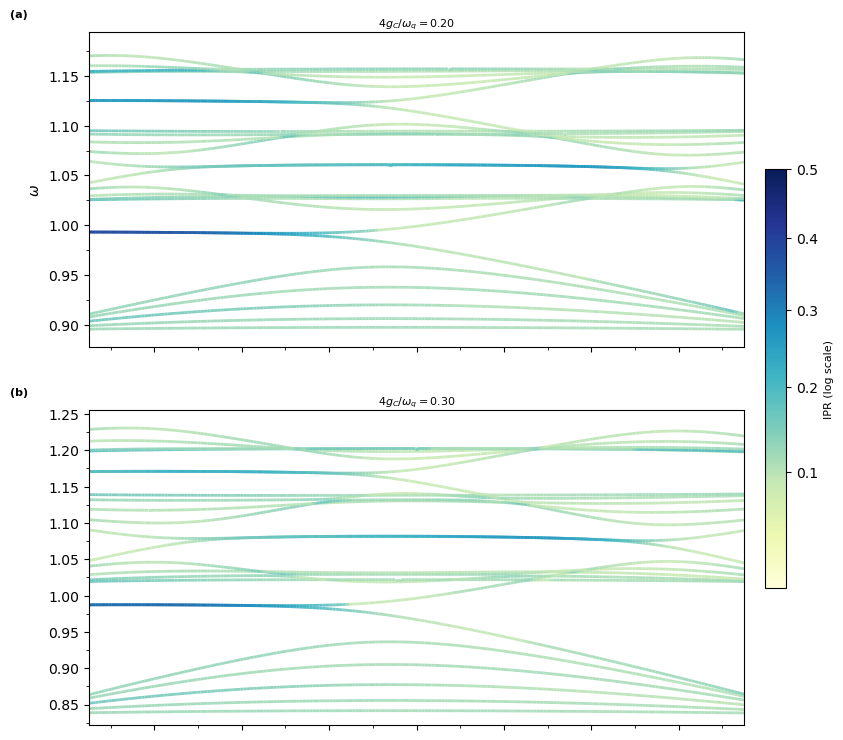

In [5]:
# ------------------------------------------------------------------ #
# Figure
# ------------------------------------------------------------------ #
nrows, ncols   = 2, 2
fig_width      = 9.0
fig_height     = 9.0
panel_fontsize = 8
cmap = plt.cm.YlGnBu
ipr_min  = 1e-4# avoid log(0)
ipr_max  = 0.5
norm_ipr = mcolors.PowerNorm(gamma=0.8, vmin=ipr_min, vmax=ipr_max)   # <-- LogNorm
# norm_ipr = mcolors.LogNorm(vmin=ipr_min, vmax=ipr_max)
fig, axes = plt.subplots(nrows=nrows, ncols=1, figsize=(fig_width, fig_height))

for idx, (Omega_C, energies, iprs) in enumerate(zip(Omega_C_values, all_energies, all_iprs)):
    ax  = axes.flatten()[idx]
    row = idx // ncols
    col = idx  % ncols

    for band_e, band_ipr in zip(energies.T, iprs.T):
        points   = np.array([Chi_C_values, band_e]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)

        lc = LineCollection(segments, cmap=cmap, norm=norm_ipr,
                            linewidth=2.0, alpha=0.9)
        log_ipr_mid = np.clip(0.5 * (band_ipr[:-1] + band_ipr[1:]), ipr_min, None)
        lc.set_array(log_ipr_mid)                                 # <-- clipped, LogNorm handles the log
        # lc.set_array(0.5 * (band_ipr[:-1] + band_ipr[1:]))
        ax.add_collection(lc)

    ax.set_xlim(Chi_C_values[0], Chi_C_values[-1])
    e_all = energies.flatten()
    ax.set_ylim(e_all.min() - 0.02 * abs(e_all.min()),
                e_all.max() + 0.02 * abs(e_all.max()))

    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.text(-0.12, 1.04, f'({chr(97 + idx)})',
            transform=ax.transAxes,
            fontsize=panel_fontsize, fontweight='bold',
            va='bottom', ha='left')
    ax.set_title(rf'$4g_C / \omega_q = {Omega_C:.2f}$', fontsize=8, pad=4)

    if row == nrows - 1:
        ax.set_xlabel(r'$\chi_C$')
    else:
        ax.tick_params(labelbottom=False)
    if col == 0:
        ax.set_ylabel(r'$\omega$')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_ipr)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation='vertical',
                    fraction=0.03, pad=0.03)
cbar.set_label(r'IPR (log scale)', fontsize=8)

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection
import scipy.sparse.linalg as sla
import scipy.sparse as sp
from ssh_chain import PHOTONICChain
from joblib import Parallel, delayed
from concurrent.futures import ProcessPoolExecutor
import functools
def make_edge_lifting_perturbation(chain, strength=1e-6):
    """
    Diagonal perturbation: delta_i = strength * (exp(-i/xi) - exp(-(2N-1-i)/xi))
    Positive on left edge sites, negative on right edge sites.
    This lifts the degeneracy without mixing the states significantly.
    """
    n     = 2 * chain.N
    xi    = n / 4.0   # decay length ~ quarter chain
    d_ph  = chain.fock_photon
    d_mat = chain.fock_dim

    # weight per site: +exp on left, -exp on right
    site_weights = np.array([np.exp(-i / xi) - np.exp(-(n - 1 - i) / xi)
                             for i in range(n)])

    # build diagonal in matter Fock basis
    diag_mat = np.zeros(d_mat)
    for exc, arr in chain.fock_states.items():
        offset = chain.fock_offsets[exc]
        for s_idx, state in enumerate(arr):
            diag_mat[offset + s_idx] = sum(
                ni * site_weights[i] for i, ni in enumerate(state))

    # tensor with photon identity
    full_diag = strength * np.tile(diag_mat, d_ph)
    return sp.diags(full_diag, format='csr')

gap_threshold = 1e-4

def resolve_edge_states(chain, scale):
    H_pert = scale * (chain.H + make_edge_lifting_perturbation(chain, strength=1e-6))

    results = {}
    for sigma_try in [1.0 + 1e-4, 1.0 - 1e-4, 1.0 + 1e-3, 1.0 - 1e-3]:
        try:
            evals, evecs = sla.eigsh(H_pert, k=6, sigma=scale * sigma_try, which='LM')
            for i, e in enumerate(evals):
                if not any(abs(e - e2) < 1e-9 for e2 in results):
                    results[e] = evecs[:, i]
            if len(results) >= 4:
                break
        except RuntimeError:
            continue

    all_energies_scaled   = np.array(sorted(results.keys()))
    all_energies_physical = all_energies_scaled / scale
    all_states            = np.column_stack([results[e] for e in all_energies_scaled])

    near_mask = np.abs(all_energies_physical - 1.0) < gap_threshold
    if near_mask.sum() < 2:
        near_mask = np.zeros(len(all_energies_physical), dtype=bool)
        near_mask[np.argsort(np.abs(all_energies_physical - 1.0))[:2]] = True

    V_near = all_states[:, near_mask]
    E_near = all_energies_physical[near_mask]

    if V_near.shape[1] > 2:
        best2  = np.argsort(np.abs(E_near - 1.0))[:2]
        V_near = V_near[:, best2]
        E_near = E_near[best2]

    e_order  = np.argsort(E_near)
    V_sorted = V_near[:, e_order]

    return V_sorted[:, 0], V_sorted[:, 1]

def old_basis_matter_vec(evec, chain):
    d_ph  = chain.fock_photon
    d_mat = chain.fock_dim

    # 1. partial trace -> leading matter eigenvector (Bogoliubov basis)
    rho_matter     = chain.partial_trace(evec, which_to_keep='matter')
    _, evecs_rho   = np.linalg.eigh(rho_matter)
    matter_vec_new = evecs_rho[:, -1]

    # 2. embed as a photon-0 state in the full tensor-product space
    synth_vec         = np.zeros(d_ph * d_mat, dtype=complex)
    synth_vec[:d_mat] = matter_vec_new

    # 3. call the class method directly
    old_decomp = chain.decompose_to_old_fock(synth_vec)
    old_sector = old_decomp.get(0, {})

    # 4. reconstruct old-basis vector
    old_vec = np.zeros(d_mat, dtype=complex)
    for state_tuple, coeff in old_sector.items():
        exc = sum(state_tuple)
        if (exc in chain.fock_state_index
                and state_tuple in chain.fock_state_index[exc]):
            s_idx = chain.fock_state_index[exc][state_tuple]
            old_vec[chain.fock_offsets[exc] + s_idx] += coeff

    return old_vec

# ------------------------------------------------------------------ #
# Helper: IPR from a full eigenvector
# ------------------------------------------------------------------ #
# def ipr_from_evec(evec, chain):
#     old_vec    = old_basis_matter_vec(evec, chain)
#     ipr, xi, _ = chain.quanta_ipr(old_vec)
#     return ipr
def ipr_from_evec(evec, chain):
    decomp_vec             = chain.decompose_to_old_fock(evec)
    comp_vec, sorted_states, _ = chain.compose_tensor_state(decomp_vec)

    d_ph  = chain.fock_photon
    d_mat = len(sorted_states)
    psi   = comp_vec.reshape(d_ph, d_mat)
    
    # diagonal of reduced matter density matrix in the inferred old basis
    diag_rho = np.sum(np.abs(psi)**2, axis=0)   # shape (d_mat,), = Σ_alpha |psi[alpha,m]|²

    # compute <n_i> = Σ_m diag_rho[m] * state_m[i]
    n            = 2 * chain.N
    distribution = np.zeros(n)
    for m, state_tuple in enumerate(sorted_states):
        distribution += diag_rho[m] * np.array(state_tuple, dtype=float)

    total = distribution.sum()
    if total < 1e-15:
        return 0.0

    ipr = np.sum(distribution**2) / total**2
    return ipr

def _ipr_one(evec, chain):
    decomp_vec                 = chain.decompose_to_old_fock(evec)
    comp_vec, sorted_states, _ = chain.compose_tensor_state(decomp_vec)

    d_ph     = chain.fock_photon
    d_mat    = len(sorted_states)
    psi      = comp_vec.reshape(d_ph, d_mat)
    diag_rho = np.sum(np.abs(psi)**2, axis=0)   # Σ_alpha |ψ[alpha,m]|²

    n    = 2 * chain.N
    dist = np.zeros(n)
    for m, state_tuple in enumerate(sorted_states):
        dist += diag_rho[m] * np.array(state_tuple, dtype=float)

    total = dist.sum()
    return 0.0 if total < 1e-15 else float(np.sum(dist**2) / total**2)

def _ipr_from_precomputed(evec, d_ph, n, psi_matrix, sorted_states_arr):
    """
    evec             : 1D eigenvector (fock_photon * fock_dim)
    d_ph             : fock_photon
    n                : 2*N
    psi_matrix       : (d_mat_old, d_ph * fock_dim) matrix where row m is
                       the old-basis amplitude vector for sorted_states_arr[m]
                       -- see pre-computation below
    sorted_states_arr: (d_mat_old, n) int array of old Fock states
    """
    # project evec onto each old basis state: amplitude[m] = <old_m | evec_full>
    # psi_matrix @ evec gives a (d_mat_old,) vector of amplitudes per old state
    # but we need this per photon sector, so psi_matrix shape is (d_ph, d_mat_old, full_dim)
    # -- see below for the cleaner formulation

    # diag_rho[m] = Σ_alpha |<alpha, old_m | psi>|²
    amplitudes = psi_matrix @ evec          # shape (d_ph * d_mat_old,)
    amplitudes = amplitudes.reshape(d_ph, -1)
    diag_rho   = np.sum(np.abs(amplitudes)**2, axis=0)   # (d_mat_old,)

    dist  = diag_rho @ sorted_states_arr   # (n,)  vectorized Σ_m diag_rho[m] * state_m
    total = dist.sum()
    return 0.0 if total < 1e-15 else float(np.sum(dist**2) / total**2)
# ------------------------------------------------------------------ #
# Parameters
# ------------------------------------------------------------------ #
N = 6
gamma_zero = 0.03
fock_photon = 4
Omega_J = 1.0
Chi_J = 0.0
base_excitations = 1
fock_layers = 0
k_states = (4 * N - 1)
Omega_C_values = [0.2, 0.3]
Chi_C_values   = np.linspace(-0.75, 0.75, 200)   # <-- changed range
# ------------------------------------------------------------------ #
# Compute spectra + IPR
# ------------------------------------------------------------------ #
all_energies = []
all_iprs     = []

for Omega_C in Omega_C_values:
    energies_list = []
    iprs_list     = []

    for Chi_C in Chi_C_values:
        print(Chi_C)
        aux     = 0.5 * Omega_C
        gamma   = gamma_zero * Omega_C / np.max(Omega_C_values)
        omega_r = 1.03 * np.sqrt(1 + aux) - np.sqrt(1 - aux)
        scale   = np.exp(10 * np.abs(Chi_C))

        chain = PHOTONICChain(N, Omega_C, Chi_C, omega_r, gamma, fock_photon,
                              Omega_J, Chi_J, False)
        chain.matter_hamiltonians(n_excitations=base_excitations, layers=fock_layers)
        chain.build_full_hamiltonian(linear_coupling= False)

        # ── bulk states: standard eigsh ──────────────────────────────
        vals, vecs = chain.get_low_lying_spectrum(k=k_states)
        idx_sort   = np.argsort(vals)
        vals       = vals[idx_sort]
        vecs       = vecs[:, idx_sort]

        # ── edge states: perturbation trick at indices N-1 and N ─────
        try:
            evec_left, evec_right = resolve_edge_states(chain, scale)
            vecs[:, N - 1] = evec_left
            vecs[:, N]     = evec_right
        except Exception:
            pass

        # ── build squeezed vacuum and cache new->old translations ────
        chain.build_squeezed_vacuum(truncation=1)

        chain._new_to_old_cache = {}
        for col in range(vecs.shape[1]):
            decomp = chain.decompose_tensor_state(vecs[:, col])
            for alpha, matter_dict in decomp.items():
                for new_state_tuple in matter_dict:
                    if new_state_tuple not in chain._new_to_old_cache:
                        chain._new_to_old_cache[new_state_tuple] = chain.new_to_old_fock(
                            np.array(new_state_tuple, dtype=int)
                        )

        # ── collect all old-basis states ─────────────────────────────
        all_old_states = set()
        for old_dict in chain._new_to_old_cache.values():
            all_old_states.update(old_dict.keys())

        sorted_states     = sorted(all_old_states, key=lambda s: (sum(s), s))
        state_to_idx      = {s: i for i, s in enumerate(sorted_states)}
        d_mat_old         = len(sorted_states)
        sorted_states_arr = np.array(sorted_states, dtype=float)   # (d_mat_old, n)

        # ── build change-of-basis matrix C: (d_mat_old, d_mat_new) ──
        d_ph  = chain.fock_photon
        d_mat = chain.fock_dim
        n     = 2 * chain.N

        C = np.zeros((d_mat_old, d_mat), dtype=complex)
        for new_state_tuple, old_dict in chain._new_to_old_cache.items():
            exc = sum(new_state_tuple)
            if exc not in chain.fock_state_index:
                continue
            if new_state_tuple not in chain.fock_state_index[exc]:
                continue
            s_idx = chain.fock_state_index[exc][new_state_tuple]
            col_c = chain.fock_offsets[exc] + s_idx
            norm  = np.sqrt(sum(abs(v)**2 for v in old_dict.values()))
            for old_state, coeff in old_dict.items():
                C[state_to_idx[old_state], col_c] += coeff / (norm if norm > 1e-15 else 1.0)

        # ── project all eigenvectors at once ─────────────────────────
        # vecs: (d_ph * d_mat, k_states)
        vecs_3d = vecs.reshape(d_ph, d_mat, k_states)              # (d_ph, d_mat, k_states)
        amp_3d  = np.tensordot(C, vecs_3d, axes=([1], [1]))        # (d_mat_old, d_ph, k_states)
        amp_3d  = amp_3d.transpose(1, 0, 2)                        # (d_ph, d_mat_old, k_states)

        # ── diagonal of reduced matter density matrix ─────────────────
        diag_rho = np.sum(np.abs(amp_3d)**2, axis=0)               # (d_mat_old, k_states)

        # ── quanta distribution and IPR for all states at once ───────
        all_dist  = sorted_states_arr.T @ diag_rho                 # (n, k_states)
        totals    = all_dist.sum(axis=0)                            # (k_states,)
        iprs_this = np.where(
            totals < 1e-15,
            0.0,
            np.sum(all_dist**2, axis=0) / totals**2
        )

        energies_list.append(vals)
        iprs_list.append(iprs_this)

    all_energies.append(np.array(energies_list))   # (n_Chi, k_states)
    all_iprs.append(np.array(iprs_list))            # (n_Chi, k_states)
    
    # ------------------------------------------------------------------ #
# Figure
# ------------------------------------------------------------------ #
nrows, ncols   = 2, 2
fig_width      = 9.0
fig_height     = 9.0
panel_fontsize = 8
cmap = plt.cm.YlGnBu
ipr_min  = 1e-4# avoid log(0)
ipr_max  = 0.5
norm_ipr = mcolors.PowerNorm(gamma=0.8, vmin=ipr_min, vmax=ipr_max)   # <-- LogNorm
# norm_ipr = mcolors.LogNorm(vmin=ipr_min, vmax=ipr_max)
fig, axes = plt.subplots(nrows=nrows, ncols=1, figsize=(fig_width, fig_height))

for idx, (Omega_C, energies, iprs) in enumerate(zip(Omega_C_values, all_energies, all_iprs)):
    ax  = axes.flatten()[idx]
    row = idx // ncols
    col = idx  % ncols

    for band_e, band_ipr in zip(energies.T, iprs.T):
        points   = np.array([Chi_C_values, band_e]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)

        lc = LineCollection(segments, cmap=cmap, norm=norm_ipr,
                            linewidth=2.0, alpha=0.9)
        log_ipr_mid = np.clip(0.5 * (band_ipr[:-1] + band_ipr[1:]), ipr_min, None)
        lc.set_array(log_ipr_mid)                                 # <-- clipped, LogNorm handles the log
        # lc.set_array(0.5 * (band_ipr[:-1] + band_ipr[1:]))
        ax.add_collection(lc)

    ax.set_xlim(Chi_C_values[0], Chi_C_values[-1])
    e_all = energies.flatten()
    ax.set_ylim(e_all.min() - 0.02 * abs(e_all.min()),
                e_all.max() + 0.02 * abs(e_all.max()))

    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.text(-0.12, 1.04, f'({chr(97 + idx)})',
            transform=ax.transAxes,
            fontsize=panel_fontsize, fontweight='bold',
            va='bottom', ha='left')
    ax.set_title(rf'$4g_C / \omega_q = {Omega_C:.2f}$', fontsize=8, pad=4)

    if row == nrows - 1:
        ax.set_xlabel(r'$\chi_C$')
    else:
        ax.tick_params(labelbottom=False)
    if col == 0:
        ax.set_ylabel(r'$\omega$')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_ipr)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation='vertical',
                    fraction=0.03, pad=0.03)
cbar.set_label(r'IPR (log scale)', fontsize=8)

plt.show()

In [14]:
import graphics_template

In [6]:
# ------------------------------------------------------------------ #
# Parameters
# ------------------------------------------------------------------ #
N = 6
gamma_zero = 0.05
fock_photon = 8
Omega_J = 1.0
Chi_J = 0.0
base_excitations = 1
k_states = (4 * N - 1)
Omega_C = 0.2   # single value
fock_layers_values = [0, 1]   # left panel: 0, right panel: 1
Chi_C_values = np.linspace(-0.75, 0.75, 20)


In [17]:
aux     = 0.5 * Omega_C
gamma   = gamma_zero
omega_r = 1.03 * np.sqrt(1 + aux) - np.sqrt(1 - aux)

In [18]:
omega_r

np.float64(0.13158981556474236)

In [ ]:
# ------------------------------------------------------------------ #
# Helper: run one Chi_C value for a given fock_layers
# ------------------------------------------------------------------ #
def compute_one(Chi_C, fock_layers):
    aux     = 0.5 * Omega_C
    gamma   = gamma_zero
    omega_r = 1.03 * np.sqrt(1 + aux) - np.sqrt(1 - aux)
    scale   = np.exp(10 * np.abs(Chi_C))

    chain = PHOTONICChain(N, Omega_C, Chi_C, omega_r, gamma, fock_photon,
                          Omega_J, Chi_J, False)
    chain.matter_hamiltonians(n_excitations=base_excitations, layers=fock_layers)
    chain.build_full_hamiltonian(linear_coupling=False)

    vals, vecs = chain.get_low_lying_spectrum(k=k_states)
    idx_sort   = np.argsort(vals)
    vals       = vals[idx_sort]
    vecs       = vecs[:, idx_sort]

    try:
        evec_left, evec_right = resolve_edge_states(chain, scale)
        vecs[:, N - 1] = evec_left
        vecs[:, N]     = evec_right
    except Exception:
        pass

    chain.build_squeezed_vacuum(truncation=1)

    chain._new_to_old_cache = {}
    for col in range(vecs.shape[1]):
        decomp = chain.decompose_tensor_state(vecs[:, col])
        for alpha, matter_dict in decomp.items():
            for new_state_tuple in matter_dict:
                if new_state_tuple not in chain._new_to_old_cache:
                    chain._new_to_old_cache[new_state_tuple] = chain.new_to_old_fock(
                        np.array(new_state_tuple, dtype=int)
                    )

    all_old_states = set()
    for old_dict in chain._new_to_old_cache.values():
        all_old_states.update(old_dict.keys())

    sorted_states     = sorted(all_old_states, key=lambda s: (sum(s), s))
    state_to_idx      = {s: i for i, s in enumerate(sorted_states)}
    d_mat_old         = len(sorted_states)
    sorted_states_arr = np.array(sorted_states, dtype=float)

    d_ph  = chain.fock_photon
    d_mat = chain.fock_dim
    n     = 2 * chain.N

    C = np.zeros((d_mat_old, d_mat), dtype=complex)
    for new_state_tuple, old_dict in chain._new_to_old_cache.items():
        exc = sum(new_state_tuple)
        if exc not in chain.fock_state_index:
            continue
        if new_state_tuple not in chain.fock_state_index[exc]:
            continue
        s_idx = chain.fock_state_index[exc][new_state_tuple]
        col_c = chain.fock_offsets[exc] + s_idx
        norm  = np.sqrt(sum(abs(v)**2 for v in old_dict.values()))
        for old_state, coeff in old_dict.items():
            C[state_to_idx[old_state], col_c] += coeff / (norm if norm > 1e-15 else 1.0)

    vecs_3d  = vecs.reshape(d_ph, d_mat, k_states)
    amp_3d   = np.tensordot(C, vecs_3d, axes=([1], [1])).transpose(1, 0, 2)
    diag_rho = np.sum(np.abs(amp_3d)**2, axis=0)
    all_dist = sorted_states_arr.T @ diag_rho
    totals   = all_dist.sum(axis=0)
    iprs_this = np.where(totals < 1e-15, 0.0, np.sum(all_dist**2, axis=0) / totals**2)

    return vals, iprs_this



In [8]:
# ------------------------------------------------------------------ #
# Compute spectra + IPR for both fock_layers values
# ------------------------------------------------------------------ #
results = {}
for fl in fock_layers_values:
    print(f"fock_layers = {fl}")
    energies_list, iprs_list = [], []
    for Chi_C in Chi_C_values:
        print(f"  Chi_C = {Chi_C:.3f}")
        vals, iprs = compute_one(Chi_C, fl)
        energies_list.append(vals)
        iprs_list.append(iprs)
    results[fl] = (np.array(energies_list), np.array(iprs_list))



fock_layers = 0
  Chi_C = -0.750
  Chi_C = -0.671
  Chi_C = -0.592
  Chi_C = -0.513
  Chi_C = -0.434
  Chi_C = -0.355
  Chi_C = -0.276
  Chi_C = -0.197
  Chi_C = -0.118
  Chi_C = -0.039
  Chi_C = 0.039
  Chi_C = 0.118
  Chi_C = 0.197
  Chi_C = 0.276
  Chi_C = 0.355
  Chi_C = 0.434
  Chi_C = 0.513
  Chi_C = 0.592
  Chi_C = 0.671
  Chi_C = 0.750
fock_layers = 1
  Chi_C = -0.750
  Chi_C = -0.671
  Chi_C = -0.592
  Chi_C = -0.513
  Chi_C = -0.434
  Chi_C = -0.355
  Chi_C = -0.276
  Chi_C = -0.197
  Chi_C = -0.118
  Chi_C = -0.039
  Chi_C = 0.039
  Chi_C = 0.118
  Chi_C = 0.197
  Chi_C = 0.276
  Chi_C = 0.355
  Chi_C = 0.434
  Chi_C = 0.513
  Chi_C = 0.592
  Chi_C = 0.671
  Chi_C = 0.750


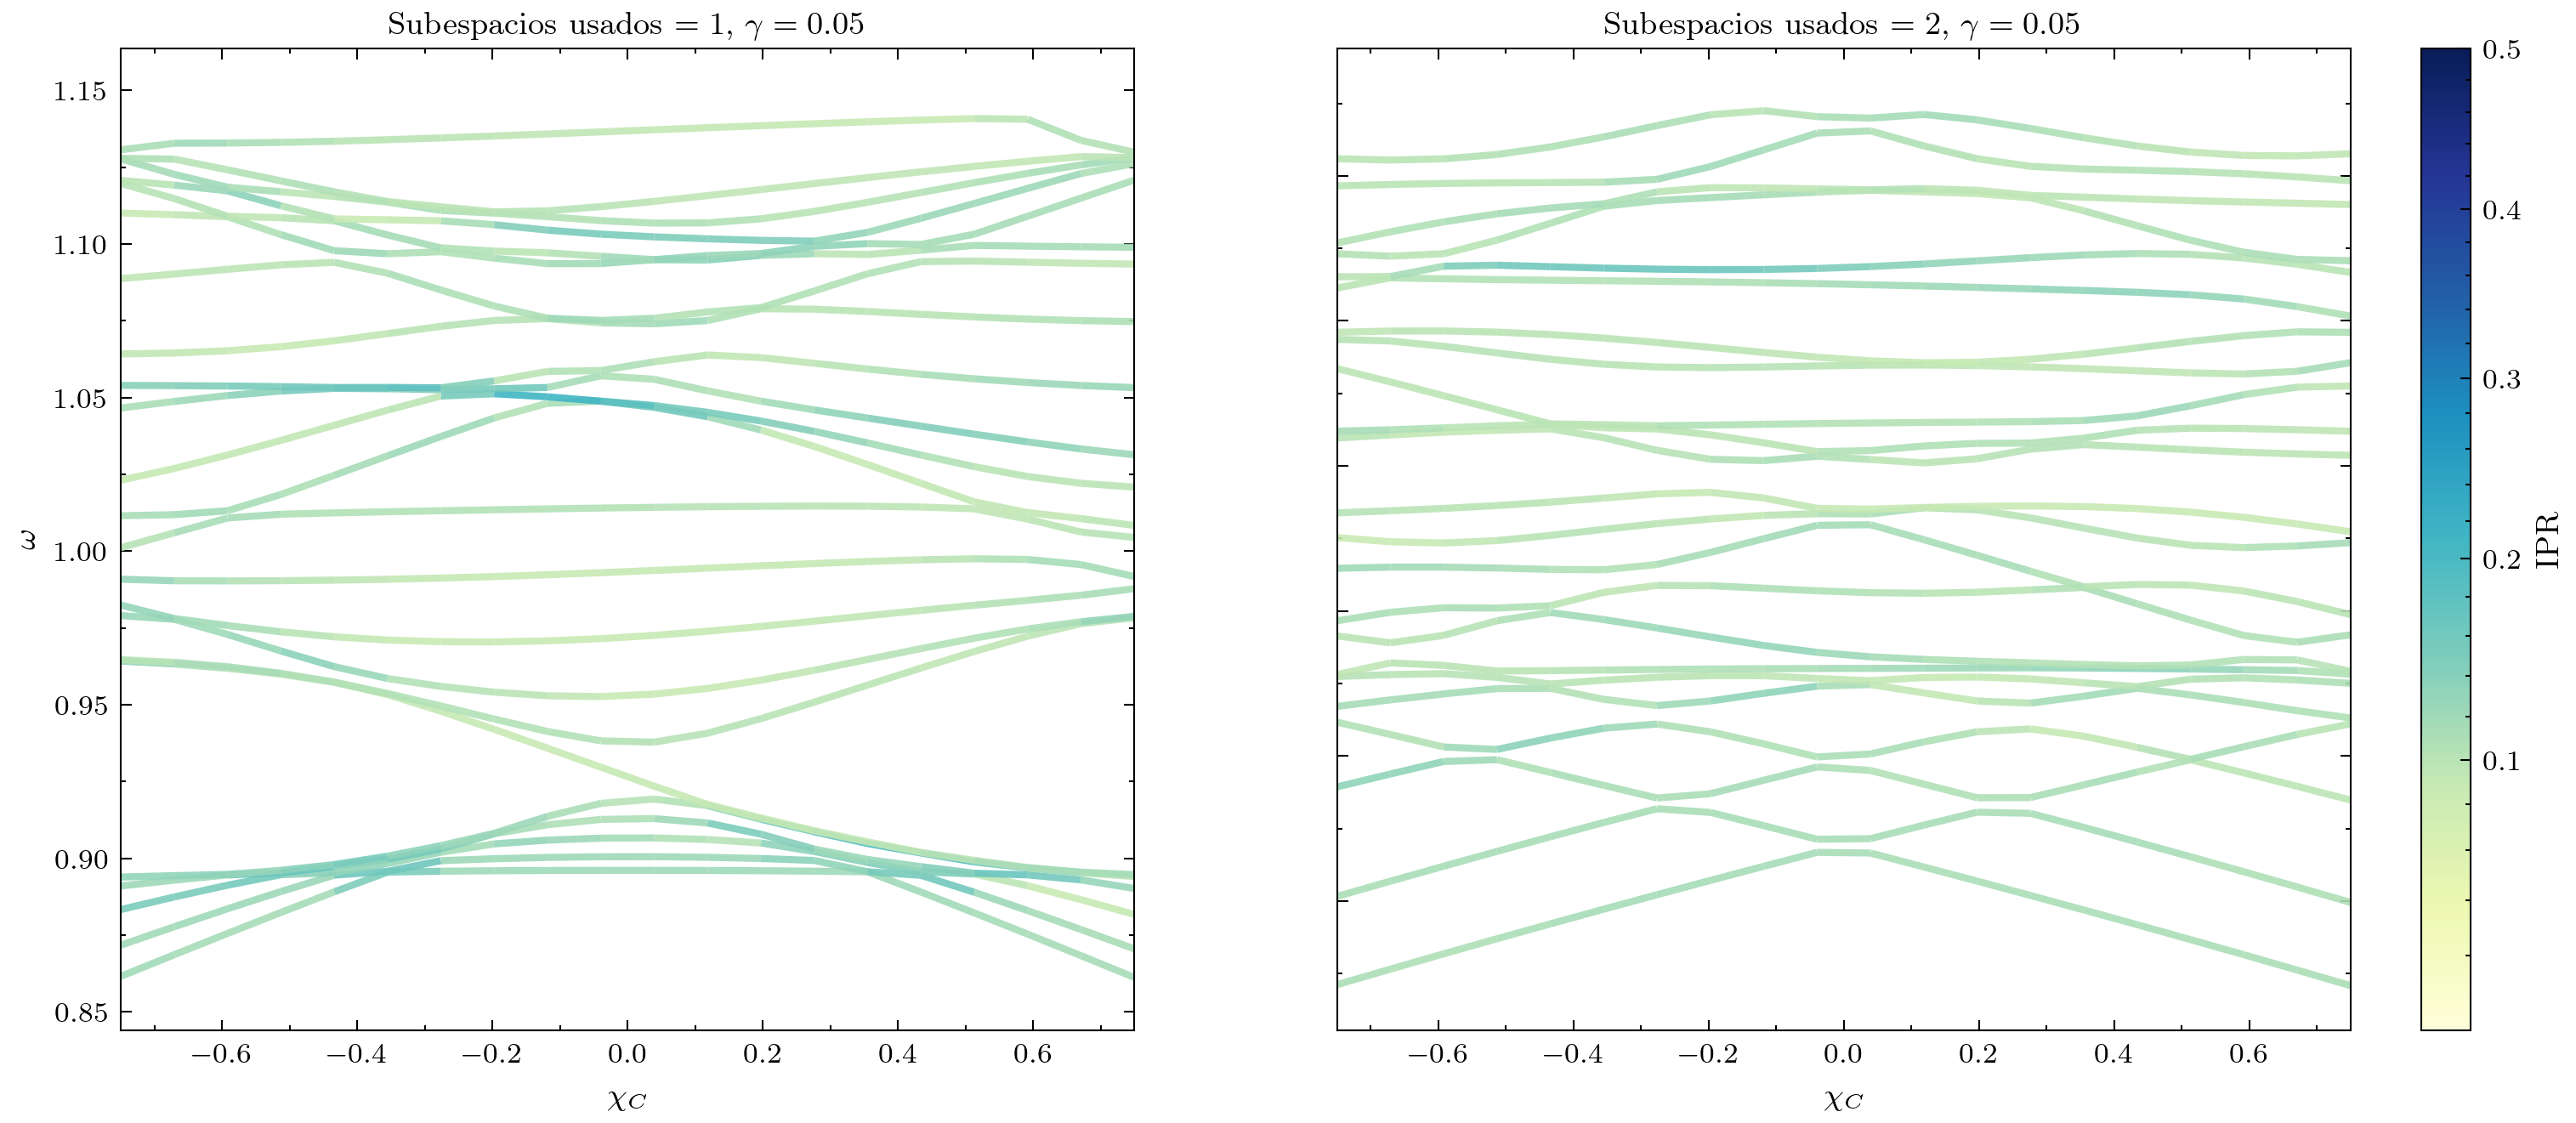

In [15]:
# ------------------------------------------------------------------ #
# Figure
# ------------------------------------------------------------------ #
cmap     = plt.cm.YlGnBu
ipr_min  = 1e-4
ipr_max  = 0.5
norm_ipr = mcolors.PowerNorm(gamma=0.8, vmin=ipr_min, vmax=ipr_max)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, fl in zip(axes, fock_layers_values):
    energies, iprs = results[fl]

    for band_e, band_ipr in zip(energies.T, iprs.T):
        points   = np.array([Chi_C_values, band_e]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        lc = LineCollection(segments, cmap=cmap, norm=norm_ipr,
                            linewidth=2.0, alpha=0.9)
        lc.set_array(np.clip(0.5 * (band_ipr[:-1] + band_ipr[1:]), ipr_min, None))
        ax.add_collection(lc)

    ax.set_xlim(Chi_C_values[0], Chi_C_values[-1])
    e_all = energies.flatten()
    ax.set_ylim(e_all.min() - 0.02 * abs(e_all.min()),
                e_all.max() + 0.02 * abs(e_all.max()))
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.set_xlabel(r'$\chi_C$')
    ax.set_title(rf'Subespacios usados $= {fl+1}$, $\gamma = {gamma_zero}$', fontsize=9, pad=4)

axes[0].set_ylabel(r'$\omega$')
axes[1].tick_params(labelleft=False)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_ipr)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation='vertical', fraction=0.03, pad=0.03)
cbar.set_label(r'IPR', fontsize=9)

# plt.tight_layout()
plt.show()

NameError: name 'omega_r' is not defined